# ENM 5310 — Aurora precipitation head fine-tuning (clean, resumable, publishable plots)

**Goal**: Train a lightweight precipitation decoder (head) on top of a **frozen AuroraSmallPretrained** backbone.

- ✅ `Run All` works end-to-end
- ✅ Auto-loads checkpoint (skip training) when `DO_TRAIN=False`
- ✅ Dense loss logging (per-sample step loss) + epoch curves
- ✅ Paper-style qualitative panels (Target / Pred / Error) in **mm** (log scale)


## 0) Config (edit only this cell)

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

# --- Paths ---
DATA_DIR = Path("./downloads/era5")  # where your NetCDFs live
OUT_DIR = Path("./runs/aurora_tp_head")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUT_DIR / "precip_head.pt"
STATS_PATH = Path("./tp_normalization.json")

# --- Split ---
def date_range(start: str, end: str):
    s = datetime.fromisoformat(start)
    e = datetime.fromisoformat(end)
    out = []
    cur = s
    while cur <= e:
        out.append(cur.strftime("%Y-%m-%d"))
        cur += timedelta(days=1)
    return out

TRAIN_DATES = date_range("2023-01-01", "2023-01-20")
VAL_DATES   = date_range("2023-01-21", "2023-01-25")

# --- Training ---
EPOCHS = 3
LR = 1e-3

# --- Run mode ---
# Set DO_TRAIN=False to skip training and only load checkpoint + plot/infer.
DO_TRAIN = True

# If DO_TRAIN=True and checkpoint exists:
# - RESUME_IF_EXISTS=True => continue from checkpoint
# - RESUME_IF_EXISTS=False => reset head and train from scratch
RESUME_IF_EXISTS = True

# --- Device strategy ---
# If you OOM, keep BACKBONE_ON_GPU=False (Aurora on CPU) and HEAD_ON_GPU=True (head on GPU).
BACKBONE_ON_GPU = False
HEAD_ON_GPU = True

print("Config loaded.")
print("TRAIN_DATES:", len(TRAIN_DATES), "| VAL_DATES:", len(VAL_DATES))
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("DO_TRAIN:", DO_TRAIN, "| RESUME_IF_EXISTS:", RESUME_IF_EXISTS)


Config loaded.
TRAIN_DATES: 20 | VAL_DATES: 5
CHECKPOINT_PATH: runs\aurora_tp_head\precip_head.pt
DO_TRAIN: True | RESUME_IF_EXISTS: True


## 1) Imports + device

In [3]:
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

from aurora import Batch, Metadata
from aurora import AuroraSmallPretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.7.1+cu128
cuda available: True
device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2) Load normalization stats (MU, STD)

In [4]:
assert STATS_PATH.exists(), "Missing tp_normalization.json"
with open(STATS_PATH, "r") as f:
    stats = json.load(f)
MU = float(stats["mean"])
STD = float(stats["std"])
print("Loaded stats:", stats)
print("MU, STD:", MU, STD)


Loaded stats: {'target': 'log1p_tp_6h', 'mean': 0.0005497062811627984, 'std': 0.0019855170976370573, 'units': 'log(1 + meters)'}
MU, STD: 0.0005497062811627984 0.0019855170976370573


## 3) Data helpers (build Batch + target)

Assumes you already have:
- `{date}-surface-level.nc`
- `{date}-atmospheric.nc`
- `{date}-tp-hourly-01_to_06.nc`
- `static.nc`


In [5]:
def build_paths(date_str: str):
    surf = DATA_DIR / f"{date_str}-surface-level.nc"
    atm  = DATA_DIR / f"{date_str}-atmospheric.nc"
    tp   = DATA_DIR / f"{date_str}-tp-hourly-01_to_06.nc"
    static = DATA_DIR / "static.nc"
    return surf, atm, tp, static

def build_batch(date_str: str) -> Batch:
    surf_path, atm_path, _, static_path = build_paths(date_str)
    assert surf_path.exists(), f"Missing {surf_path}"
    assert atm_path.exists(),  f"Missing {atm_path}"
    assert static_path.exists(), f"Missing {static_path}"

    static_ds = xr.open_dataset(static_path)
    surf_ds   = xr.open_dataset(surf_path)
    atm_ds    = xr.open_dataset(atm_path)

    # 2 time steps (t0, t1)
    b = Batch(
        surf_vars={
            "2t":  torch.from_numpy(surf_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z":   torch.from_numpy(static_ds["z"].values[0]),
            "slt": torch.from_numpy(static_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atm_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atm_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atm_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atm_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atm_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_ds.latitude.values),
            lon=torch.from_numpy(surf_ds.longitude.values),
            time=(surf_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(l) for l in atm_ds.pressure_level.values),
        ),
    )

    static_ds.close(); surf_ds.close(); atm_ds.close()
    return b

def build_target(date_str: str) -> torch.Tensor:
    """Returns y_norm [1,1,720,1440] on CPU. Target is log1p(meters) normalized."""
    _, _, tp_path, _ = build_paths(date_str)
    assert tp_path.exists(), f"Missing {tp_path}"
    tp_ds = xr.open_dataset(tp_path)
    tp = tp_ds["tp"]
    tp6h = tp.sum(dim="valid_time")  # meters
    y = torch.from_numpy(tp6h.values.astype("float32"))
    y_log = torch.log1p(y)
    y_bchw = y_log[None, None].contiguous()
    y_norm = (y_bchw - MU) / STD
    y_norm = y_norm[:, :, :720, :].contiguous()  # safety crop
    tp_ds.close()
    return y_norm


## 4) Feature packing (Aurora output → head input)

In [6]:
def pack_surf_features(pred_batch: Batch) -> torch.Tensor:
    x2t  = pred_batch.surf_vars["2t"]
    x10u = pred_batch.surf_vars["10u"]
    x10v = pred_batch.surf_vars["10v"]
    xmsl = pred_batch.surf_vars["msl"]
    X = torch.cat([x2t, x10u, x10v, xmsl], dim=1).float()  # [B,4,H,W]
    # per-channel standardization per sample
    mean = X.mean(dim=(2,3), keepdim=True)
    std  = X.std(dim=(2,3), keepdim=True).clamp_min(1e-6)
    return (X - mean) / std


## 5) Model (Aurora frozen) + head (trainable) + checkpoint load

In [7]:
class PrecipHead(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)

# Backbone (frozen)
model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

# Head
head = PrecipHead(in_ch=4)

# Device placement
if BACKBONE_ON_GPU and device.type == "cuda":
    model = model.to("cuda")
else:
    model = model.to("cpu")
if HEAD_ON_GPU and device.type == "cuda":
    head = head.to("cuda")
else:
    head = head.to("cpu")

print("Backbone device:", next(model.parameters()).device)
print("Head device:", next(head.parameters()).device)

# History (dense + epoch)
history = {
    "train_loss": [], "val_loss": [], "val_corr": [],
    "train_step_loss": [], "train_step_dates": [],
    "val_day_loss": [], "val_day_corr": [], "val_day_dates": [],
}

# Optional: load checkpoint (always safe)
if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    if (not DO_TRAIN) or RESUME_IF_EXISTS:
        head.load_state_dict(ckpt["head_state_dict"])
        head.eval()
        if "history" in ckpt:
            history = ckpt["history"]
        print(f"✓ Loaded checkpoint: {CHECKPOINT_PATH}")
        if len(history.get("train_loss", [])):
            print("  last train_loss:", history["train_loss"][-1])
        if len(history.get("val_loss", [])):
            print("  last val_loss:", history["val_loss"][-1])
        if len(history.get("val_corr", [])):
            print("  last val_corr:", history["val_corr"][-1])
    else:
        print("Checkpoint exists but RESUME_IF_EXISTS=False => will train head from scratch")
else:
    print("No checkpoint found yet.")


Backbone device: cpu
Head device: cuda:0
✓ Loaded checkpoint: runs\aurora_tp_head\precip_head.pt
  last train_loss: 0.14921671524643898
  last val_loss: 0.16352943181991578
  last val_corr: 0.2685356378555298


## 6) Train/eval helpers (head-only)

- Aurora forward is always in `no_grad()`
- Head is trained normally
- We aggressively delete tensors to avoid VRAM bloat


In [8]:
loss_fn = nn.SmoothL1Loss(beta=1.0)
opt = optim.Adam(head.parameters(), lr=LR)

def move_batch(b: Batch, dev: torch.device) -> Batch:
    return b.to(str(dev))

def corrcoef_map(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.detach().float().view(-1)
    b = b.detach().float().view(-1)
    a = a - a.mean(); b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(1e-12)
    return float((a * b).mean() / denom)

@torch.no_grad()
def eval_one(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    pred = model(b_dev)
    X = pack_surf_features(pred).to(h_dev)
    y = y.to(h_dev)

    yhat = head(X)
    loss = float(loss_fn(yhat, y).item())
    corr = corrcoef_map(yhat.to("cpu"), y.to("cpu"))

    del b, b_dev, pred, X, y, yhat
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return loss, corr

def train_one_epoch(dates):
    model.eval()
    head.train()

    step_losses = []
    dates_seen = []

    for i, date_str in enumerate(dates):
        b = build_batch(date_str)
        y = build_target(date_str)  # CPU

        bb_dev = next(model.parameters()).device
        h_dev  = next(head.parameters()).device
        b_dev = move_batch(b, bb_dev)

        # Aurora forward (no grad)
        with torch.no_grad():
            pred = model(b_dev)
            X = pack_surf_features(pred)

        # Safe: make X a normal tensor for head training
        X = X.clone().to(h_dev)
        y = y.to(h_dev)

        opt.zero_grad(set_to_none=True)
        yhat = head(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

        step_losses.append(float(loss.item()))
        dates_seen.append(date_str)

        del b, b_dev, pred, X, y, yhat, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

        print(f"  train {i+1:02d}/{len(dates)} | loss {step_losses[-1]:.6f} | {date_str}")

    return float(np.mean(step_losses)) if len(step_losses) else float("nan"), dates_seen, step_losses


## 7) Train (optional) + save checkpoint

- If `DO_TRAIN=False`: skip training (but you can still plot/infer).
- If training runs: saves after every epoch.


In [ ]:
print("DO_TRAIN:", DO_TRAIN)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("TRAIN_DATES:", len(TRAIN_DATES), "| VAL_DATES:", len(VAL_DATES))

if DO_TRAIN:
    # If checkpoint exists and we do NOT want to resume, reset head
    if CHECKPOINT_PATH.exists() and (not RESUME_IF_EXISTS):
        print("Resetting head params (training from scratch)")
        head.apply(lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None)
        history = {
            "train_loss": [], "val_loss": [], "val_corr": [],
            "train_step_loss": [], "train_step_dates": [],
            "val_day_loss": [], "val_day_corr": [], "val_day_dates": [],
        }

    for ep in range(EPOCHS):
        print(f"\n=== Epoch {ep+1}/{EPOCHS} ===")

        train_loss, step_dates, step_losses = train_one_epoch(TRAIN_DATES)
        history["train_loss"].append(train_loss)
        history["train_step_loss"].append(step_losses)
        history["train_step_dates"].append(step_dates)

        if len(VAL_DATES) > 0:
            vals = [eval_one(d) for d in VAL_DATES]
            day_losses = [float(v[0]) for v in vals]
            day_corrs  = [float(v[1]) for v in vals]
            val_loss = float(np.mean(day_losses))
            val_corr = float(np.mean(day_corrs))

            history["val_day_loss"].append(day_losses)
            history["val_day_corr"].append(day_corrs)
            history["val_day_dates"].append(list(VAL_DATES))
        else:
            val_loss = float("nan")
            val_corr = float("nan")

        history["val_loss"].append(val_loss)
        history["val_corr"].append(val_corr)

        print(f"Epoch {ep+1}: train={train_loss:.6f} | val={val_loss:.6f} | corr={val_corr:.4f}")

        torch.save(
            {
                "head_state_dict": head.state_dict(),
                "config": {
                    "TRAIN_DATES": TRAIN_DATES,
                    "VAL_DATES": VAL_DATES,
                    "LR": LR,
                    "EPOCHS": EPOCHS,
                    "BACKBONE_ON_GPU": BACKBONE_ON_GPU,
                    "HEAD_ON_GPU": HEAD_ON_GPU,
                    "MU": MU,
                    "STD": STD,
                    "LOSS": "SmoothL1Loss(beta=1.0)",
                },
                "history": history,
            },
            CHECKPOINT_PATH,
        )
        print("Saved:", CHECKPOINT_PATH)

else:
    if not CHECKPOINT_PATH.exists():
        print("DO_TRAIN=False but no checkpoint exists. Set DO_TRAIN=True once.")
    else:
        print("Skipping training; checkpoint already loaded (if present).")


DO_TRAIN: True
Checkpoint exists: True
TRAIN_DATES: 20 | VAL_DATES: 5

=== Epoch 1/20 ===


## 8) Publishable training curves (dense + epoch)

- Dense: loss per training sample (all epochs concatenated)
- Epoch: train/val mean loss + val correlation


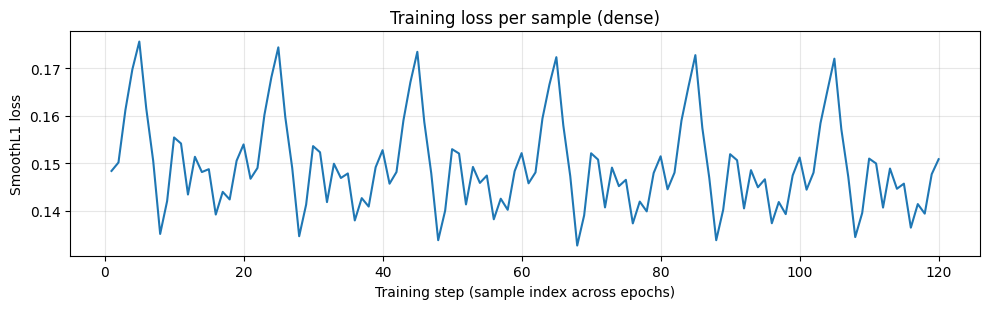

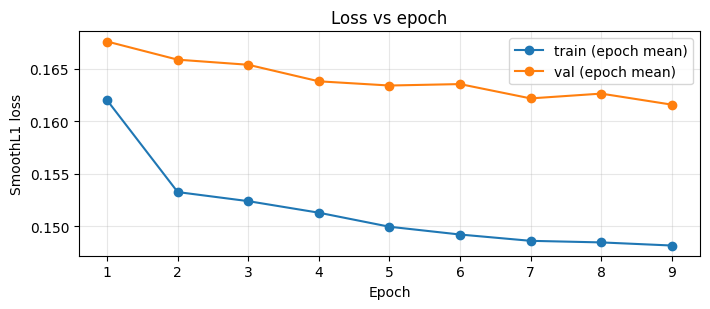

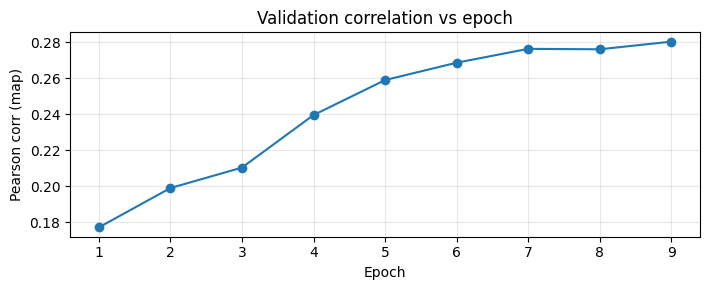

In [10]:
def _flatten_steps(history_key: str):
    xs = history.get(history_key, [])
    if not xs:
        return None
    return np.concatenate([np.array(v, dtype=float) for v in xs])

# Dense step loss
dense = _flatten_steps("train_step_loss")
if dense is not None and len(dense):
    x = np.arange(1, len(dense) + 1)
    plt.figure(figsize=(10, 3.2))
    plt.plot(x, dense)
    plt.title("Training loss per sample (dense)")
    plt.xlabel("Training step (sample index across epochs)")
    plt.ylabel("SmoothL1 loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No dense train_step_loss found.")

# Epoch curves
epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
if len(epochs):
    plt.figure(figsize=(7.2, 3.2))
    plt.plot(epochs, history["train_loss"], marker="o", label="train (epoch mean)")
    if len(history.get("val_loss", [])) == len(epochs):
        plt.plot(epochs, history["val_loss"], marker="o", label="val (epoch mean)")
    plt.title("Loss vs epoch")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(history.get("val_corr", [])) == len(epochs):
        plt.figure(figsize=(7.2, 3.0))
        plt.plot(epochs, history["val_corr"], marker="o")
        plt.title("Validation correlation vs epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Pearson corr (map)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No epoch history found.")


## 9) Paper-style qualitative panels (Target / Pred / Error)

- Converts normalized log1p(meters) → **mm**
- Precip panels use **log color scale**
- Error panel uses **diverging** scale centered at 0


In [11]:
def denorm_to_mm(y_norm: torch.Tensor, mu=MU, std=STD) -> torch.Tensor:
    """y_norm: [1,1,H,W] -> returns [H,W] in mm on CPU."""
    y_log = y_norm * std + mu
    y_m   = torch.expm1(y_log).clamp_min(0.0)
    return (y_m * 1000.0).squeeze().detach().to("cpu")

@torch.no_grad()
def predict_norm(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y_true = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    with torch.no_grad():
        pred = model(b_dev)
        X = pack_surf_features(pred).clone().to(h_dev)
        y_pred = head(X).detach().to("cpu")

    lat = b.metadata.lat.detach().to("cpu")
    lon = b.metadata.lon.detach().to("cpu")

    del b, b_dev, pred, X
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_true, y_pred, lat, lon

def lon_to_0360(x: float) -> float:
    return float(x) % 360.0

def crop_latlon(arr_hw: np.ndarray, lat: np.ndarray, lon: np.ndarray,
                lat_min: float, lat_max: float, lon_min: float, lon_max: float):
    lat_lo, lat_hi = min(lat_min, lat_max), max(lat_min, lat_max)
    lat_mask = (lat >= lat_lo) & (lat <= lat_hi)
    lo = lon_to_0360(lon_min)
    hi = lon_to_0360(lon_max)
    if lo <= hi:
        lon_mask = (lon >= lo) & (lon <= hi)
        out = arr_hw[np.ix_(lat_mask, lon_mask)]
        return out, lat[lat_mask], lon[lon_mask]
    # wrap-around
    lon_mask1 = (lon >= lo)
    lon_mask2 = (lon <= hi)
    out1 = arr_hw[np.ix_(lat_mask, lon_mask1)]
    out2 = arr_hw[np.ix_(lat_mask, lon_mask2)]
    out = np.concatenate([out1, out2], axis=1)
    lon_out = np.concatenate([lon[lon_mask1], lon[lon_mask2]])
    return out, lat[lat_mask], lon_out

def pearson_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.reshape(-1).astype(np.float64)
    b = b.reshape(-1).astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    denom = (a.std() * b.std()) + 1e-12
    return float((a * b).mean() / denom)


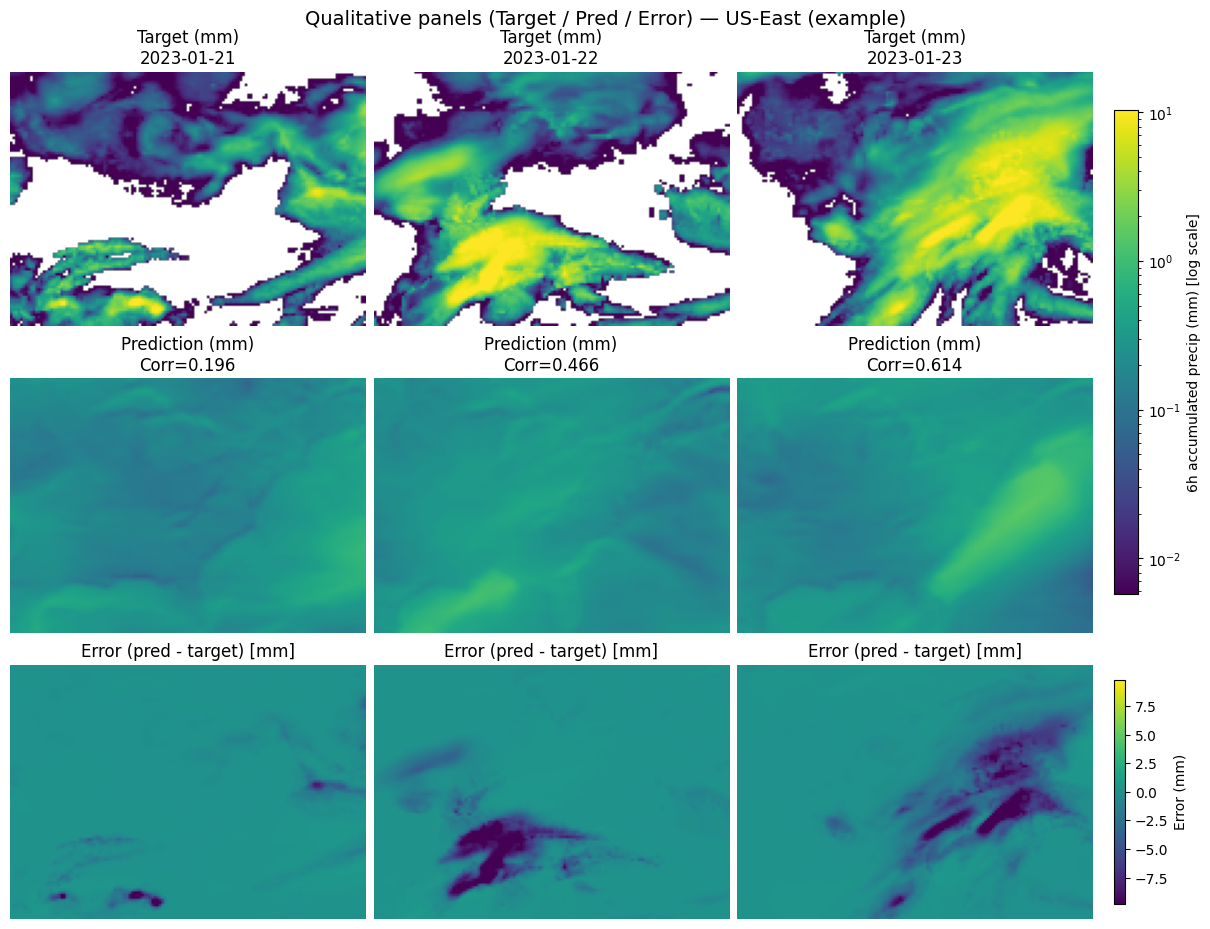

In [12]:
# ---- choose dates ----
SHOW_DATES = (VAL_DATES[:3] if len(VAL_DATES) else TRAIN_DATES[:3])

# ---- region (optional) ----
USE_REGION = True
REGION = {
    "name": "US-East (example)",
    "lat_min": 25, "lat_max": 50,
    "lon_min": 260, "lon_max": 295,  # 0..360 convention
}

cases = []
for d in SHOW_DATES:
    y_true_n, y_pred_n, lat_t, lon_t = predict_norm(d)
    y_true_mm = denorm_to_mm(y_true_n).numpy()
    y_pred_mm = denorm_to_mm(y_pred_n).numpy()
    err_mm = (y_pred_mm - y_true_mm)

    lat = lat_t.numpy()
    lon = lon_t.numpy()

    if USE_REGION:
        y_true_mm, lat, lon = crop_latlon(y_true_mm, lat, lon, REGION["lat_min"], REGION["lat_max"], REGION["lon_min"], REGION["lon_max"])
        y_pred_mm, _, _ = crop_latlon(y_pred_mm, lat_t.numpy(), lon_t.numpy(), REGION["lat_min"], REGION["lat_max"], REGION["lon_min"], REGION["lon_max"])
        err_mm,    _, _ = crop_latlon(err_mm,    lat_t.numpy(), lon_t.numpy(), REGION["lat_min"], REGION["lat_max"], REGION["lon_min"], REGION["lon_max"])

    corr = pearson_corr(y_true_mm, y_pred_mm)
    cases.append((d, y_true_mm, y_pred_mm, err_mm, corr))

# shared precip limits (log)
eps = 1e-3  # mm
all_pp = np.concatenate([np.ravel(c[1]) for c in cases] + [np.ravel(c[2]) for c in cases])
pos = all_pp[all_pp > 0]
vmin = max(eps, np.percentile(pos, 5)) if len(pos) else eps
vmax = np.percentile(all_pp, 99.5) if len(all_pp) else 1.0

# error symmetric limits
all_err = np.concatenate([np.ravel(c[3]) for c in cases])
eabs = max(1e-3, np.percentile(np.abs(all_err), 99.0))

n = len(cases)
fig, axes = plt.subplots(3, n, figsize=(4*n, 9), constrained_layout=True)
if n == 1:
    axes = np.array(axes).reshape(3, 1)

for j, (d, y_t, y_p, e, corr) in enumerate(cases):
    ax0, ax1, ax2 = axes[0, j], axes[1, j], axes[2, j]
    im0 = ax0.imshow(y_t, norm=LogNorm(vmin=vmin, vmax=vmax))
    ax0.set_title(f"Target (mm)\n{d}")
    ax0.axis("off")

    im1 = ax1.imshow(y_p, norm=LogNorm(vmin=vmin, vmax=vmax))
    ax1.set_title(f"Prediction (mm)\nCorr={corr:.3f}")
    ax1.axis("off")

    im2 = ax2.imshow(e, norm=TwoSlopeNorm(vmin=-eabs, vcenter=0.0, vmax=eabs))
    ax2.set_title("Error (pred - target) [mm]")
    ax2.axis("off")

cbar0 = fig.colorbar(im0, ax=axes[0, :].tolist() + axes[1, :].tolist(), shrink=0.85, pad=0.02)
cbar0.set_label("6h accumulated precip (mm) [log scale]")
cbar1 = fig.colorbar(im2, ax=axes[2, :].tolist(), shrink=0.85, pad=0.02)
cbar1.set_label("Error (mm)")

title_region = f" — {REGION['name']}" if USE_REGION else ""
fig.suptitle(f"Qualitative panels (Target / Pred / Error){title_region}", y=1.02, fontsize=14)
plt.show()
